In [1]:
# Import Statements

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

import os
import shutil
import pathlib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow import keras
from keras import metrics



In [2]:
# import data

path = '/Users/brentarakaki/Desktop/Berkeley/Classes/DATASCI 207 - ML/data/DeepFashion/'

category_lookup = pd.read_csv(path + 'Anno_fine/list_category_cloth.txt', 
                             sep=r'\s+',
                             header=1)

category_lookup['category_number'] = np.arange(1,51)

def create_img_df(dataset):
    valid_dataset = ['train', 'val', 'test']

    if str.lower(dataset) in valid_dataset:
        dfpath = path + 'Anno_fine/' + str.lower(dataset)
        img = pd.read_csv(dfpath+ '.txt',
                                sep=' ',
                                header=None)

        category = pd.read_csv(dfpath + '_cate.txt', 
                                     sep=r'\s+',
                                     header=None)

        img['category'] = category

        img_df = img.merge(category_lookup, left_on= 'category', right_on='category_number', how='left')[[0, 'category_type']]

        return img_df
    else:
        raise TypeError("not valid dataset type. Must pick train, val or test")



In [3]:
train_df    = create_img_df('train')
val_df      = create_img_df('val')
test_df     = create_img_df('test')

In [4]:
IMG_SIZE = (224, 224)

def load_data(dataframe):
    '''Load 2D images and their corresponding labels
    Parameters:
    dataframe (str): This is the type of data we are interested
    
    Returns:
    images (np.ndarray): A numpy array of shape (N, 224, 224, 3)
    labels (np.ndarray): A numpy array of shape (N)
    
    '''
    ## load images and labels
    images_list = []
    labels_list = []

    for i in np.arange(len(dataframe)):
        imgpath = os.path.join(path, dataframe[0][i])
        img = tf.io.read_file(imgpath)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img /= 255.0
        images_list.append(img)
        labels_list.append(dataframe['category_type'][i])

    images = np.array(images_list)
    labels = np.array(labels_list)

    return images, labels

In [5]:
train_images, train_labels = load_data(train_df)


In [6]:
print(f"""Image Shape: {train_images.shape}
Label shape: {train_labels.shape}""")

Image Shape: (14000, 224, 224, 3)
Label shape: (14000,)


In [7]:
val_images, val_labels = load_data(val_df)


In [8]:
print(f"""Image Shape: {val_images.shape}
Label shape: {val_labels.shape}""")

Image Shape: (2000, 224, 224, 3)
Label shape: (2000,)


In [9]:
test_images, test_labels = load_data(test_df)

In [10]:
print(f"""Image Shape: {test_images.shape}
Label shape: {test_labels.shape}""")

Image Shape: (4000, 224, 224, 3)
Label shape: (4000,)


In [11]:
def data_preprocessing(X, y):
    '''Apply transformations and augmentations to training, validation, and test data;
    
    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)   
    data_partition (str): "train"
    
    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    
    '''

    X_augm = tf.image.random_flip_left_right(X) # FILL IN CODE HERE #

    # concatenate original X and augmented X_aug data
    X = tf.concat([X, X_augm], axis = 0) # FILL IN CODE HERE #

    # concatenate y_train (note the label is preserved)
    y_augm = y
    y = tf.concat([y, y_augm],axis=0)

    # shuffle X and y, i.e., shuffle two tensors in the same order
    shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
    X = tf.gather(X, shuffle).numpy() # transform X back to numpy array instead of tensor
    y = tf.gather(y, shuffle).numpy() # transform y back to numpy array instead of tensor
        
        
    # rescale image by dividing each pixel by 255.0 
    # FILL IN CODE HERE #
    
    return X, y

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='accuracy', 
verbose=1,
patience=5,
mode='max',
restore_best_weights=True)

In [14]:
tf.random.set_seed(1234)
np.random.seed(1234)

# initialize model
model_tf = tf.keras.Sequential()

# add convolutional layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Conv2D(
    filters=12,
    kernel_size=6,
    strides=(2,2),
    padding= 'same',
    data_format='channels_last',
    name='conv_1',
    activation='relu'))

model_tf.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))
model_tf.add(tf.keras.layers.Dropout(rate=0.3))

model_tf.add(tf.keras.layers.Conv2D(
    filters=12,
    kernel_size=4,
    strides=(1,1),
    padding= 'same',
    data_format='channels_last',
    name='conv_2',
    activation='relu'))

model_tf.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))
model_tf.add(tf.keras.layers.Dropout(rate=0.3))

# add a flattening layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Flatten())

# add the classification layer
### YOUR CODE HERE ###
model_tf.add(tf.keras.layers.Dense(
    units=1, 
    activation='sigmoid'))

# build and compile model
model_tf.build(input_shape=(None, 224, 224, 3))
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']) 

# print model_tf summary
### YOUR CODE HERE ###
model_tf.summary()

# train model_tf on (X_train, y_train) data
### YOUR CODE HERE ###
history = model_tf.fit(
    train_images,
    train_labels,
    validation_data= (val_images, val_labels),
    epochs = 20,
    callbacks=[early_stopping]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 112, 112, 12)   │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 56, 56, 12)     │         2,316 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         9,409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,033 (50.91 KB)

 Trainable params: 13,033 (50.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 61s 133ms/step - accuracy: 0.4545 - loss: -11412262879232.0000 - val_accuracy: 0.4390 - val_loss: -49670659244032.0000
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.4551 - loss: -193739733598208.0000 - val_accuracy: 0.4390 - val_loss: -414715834531840.0000
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.4551 - loss: -813677661913088.0000 - val_accuracy: 0.4390 - val_loss: -1323802738819072.0000
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 53s 119ms/step - accuracy: 0.4551 - loss: -2051855530065920.0000 - val_accuracy: 0.4390 - val_loss: -2918358873800704.0000
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 52s 119ms/step - accuracy: 0.4551 - loss: -4022132988182528.0000 - val_accuracy: 0.4390 - val_loss: -5290934778462208.0000
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 49s 111ms/step - accuracy: 0.4551 - loss: -6804542993727488.0000 - val_accuracy: 0.4390 - val_loss: -8508621197410304.0000
Epoch 7/20
438/438 ━━━━━━━━━━━

Text(0.5, 1.0, 'Epoch vs. Loss')

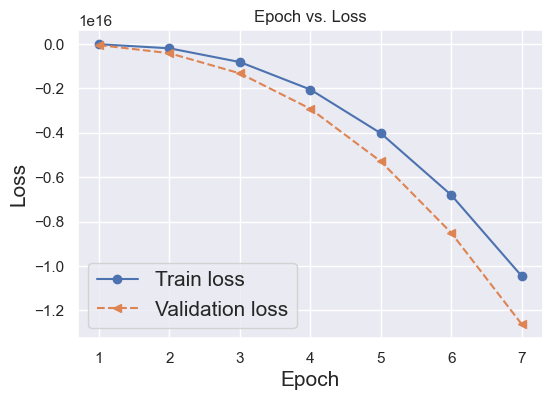

In [16]:

# plot loss curves
### YOUR CODE HERE ###
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(6, 4))
plt.plot(x_arr, hist['loss'], '-o', label='Train loss')
plt.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
plt.legend(fontsize=15)
plt.xlabel('Epoch', size=15)
plt.ylabel('Loss', size=15)
plt.title('Epoch vs. Loss')

In [24]:
np.unique(test_labels, return_counts=True)

(array([1, 2, 3]), array([1873,  779, 1348]))